#  FIFA World Cup 2026 — Model Training



| Step | Description |
|------|-------------|
| 1 | Load & split data (train on all matches, evaluate on WC-only) |
| 2 | Train Logistic Regression, Random Forest, XGBoost |
| 3 | Cross-validate with time-aware splits |
| 4 | Compare accuracy + calibrated probabilities |
| 5 | Feature importance analysis |
| 6 | Save best model to disk |

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
import pickle
import os
from pathlib import Path

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, cross_val_predict, RandomizedSearchCV
from sklearn.metrics         import (accuracy_score, classification_report,
                                      confusion_matrix, log_loss, ConfusionMatrixDisplay)
from sklearn.calibration     import CalibratedClassifierCV
from xgboost                 import XGBClassifier

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.facecolor'] = '#0e1117'
matplotlib.rcParams['axes.facecolor']   = '#0e1117'
matplotlib.rcParams['text.color']       = 'white'
matplotlib.rcParams['axes.labelcolor']  = 'white'
matplotlib.rcParams['xtick.color']      = 'white'
matplotlib.rcParams['ytick.color']      = 'white'

BASE_DIR  = Path('')
PROC_DIR  = BASE_DIR / 'data' / 'processed'
MODEL_DIR = BASE_DIR / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLS = [
    # ELO
    'home_elo_before', 'away_elo_before', 'elo_diff',
    # Rank
    'home_elo_rank', 'away_elo_rank', 'rank_diff',
    # Form — 3-match window
    'home_win_rate_3', 'away_win_rate_3', 'win_rate_diff_3',
    'home_avg_gf_3', 'home_avg_ga_3', 'home_avg_gd_3',
    'away_avg_gf_3', 'away_avg_ga_3', 'away_avg_gd_3', 'gd_diff_3',
    # Form — 5-match window
    'home_win_rate_5', 'away_win_rate_5', 'win_rate_diff_5',
    'home_avg_gf_5', 'home_avg_ga_5', 'home_avg_gd_5',
    'away_avg_gf_5', 'away_avg_ga_5', 'away_avg_gd_5', 'gd_diff_5',
    # Form — 10-match window
    'home_win_rate_10', 'away_win_rate_10', 'win_rate_diff_10',
    'home_avg_gf_10', 'home_avg_ga_10', 'home_avg_gd_10',
    'away_avg_gf_10', 'away_avg_ga_10', 'away_avg_gd_10', 'gd_diff_10',
    # H2H
    'h2h_games', 'h2h_home_wins', 'h2h_draws', 'h2h_away_wins',
    ###'h2h_home_goals', 'h2h_away_goals',  'h2h_avg_goal_diff', 'h2h_home_win_rate',  ##highly correlated with h2h_home_win_rate_3/5/10
    'h2h_home_win_rate_w',
    # Context
    'is_neutral', 'home_days_rest', 'away_days_rest',
]
TARGET = 'result'   # 0=Away win, 1=Draw, 2=Home win

df_check = pd.read_csv(PROC_DIR / 'features_all_matches.csv', nrows=1)
missing = [c for c in FEATURE_COLS if c not in df_check.columns]
if missing:
    raise ValueError(f"FEATURE_COLS references columns not in saved CSV: {missing}")
print(f'✅ Setup complete')
print(f'   Feature columns : {len(FEATURE_COLS)}')

✅ Setup complete
   Feature columns : 44


---
## 1. Load & Split Data

In [2]:
# Load feature matrices
df_all = pd.read_csv(PROC_DIR / 'features_all_matches.csv', parse_dates=['date'])
df_wc  = pd.read_csv(PROC_DIR / 'features_wc_only.csv',    parse_dates=['date'])

# Sort chronologically — critical for time-series CV
df_all = df_all.sort_values('date').reset_index(drop=True)
df_wc  = df_wc.sort_values('date').reset_index(drop=True)

X_all = df_all[FEATURE_COLS]
y_all = df_all[TARGET]

X_wc  = df_wc[FEATURE_COLS]
y_wc  = df_wc[TARGET]

# Time-based split: train pre-2018, test 2018+
cutoff     = pd.Timestamp('2018-01-01')
cal_cutoff = pd.Timestamp('2015-01-01')   # calibration slice

train_mask = df_all['date'] < cal_cutoff
cal_mask   = (df_all['date'] >= cal_cutoff) & (df_all['date'] < cutoff)
test_mask  = df_all['date'] >= cutoff

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_cal,   y_cal   = X_all[cal_mask],   y_all[cal_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

# WC-only test slice for directional evaluation
wc_test_mask = test_mask & (df_all['tournament'] == 'FIFA World Cup')
X_test_wc    = X_all[wc_test_mask]
y_test_wc    = y_all[wc_test_mask]

# X_wc / y_wc reserved for WC-specific CV only
# Do NOT use as primary training data — only ~552 matches

print(f'Training set     : {len(X_train):,} matches (before 2015)')
print(f'Calibration set  : {len(X_cal):,} matches (2015–2017)')
print(f'Test set (all)   : {len(X_test):,} matches (2018+)')
print(f'Test set (WC)    : {len(X_test_wc):,} WC matches only')

print(f'\nAll-tournament test distribution:')
print(y_test.value_counts().sort_index().rename({0:'Away', 1:'Draw', 2:'Home'}))
print(f'\nWC-only test distribution:')
print(y_test_wc.value_counts().sort_index().rename({0:'Away', 1:'Draw', 2:'Home'}))
print(f'\nTest set year distribution:')
print(df_all[test_mask]['date'].dt.year.value_counts().sort_index().to_string())

Training set     : 20,833 matches (before 2015)
Calibration set  : 2,862 matches (2015–2017)
Test set (all)   : 8,075 matches (2018+)
Test set (WC)    : 128 WC matches only

All-tournament test distribution:
result
Away    2354
Draw    1865
Home    3856
Name: count, dtype: int64

WC-only test distribution:
result
Away    47
Draw    28
Home    53
Name: count, dtype: int64

Test set year distribution:
date
2018     919
2019    1142
2020     347
2021    1115
2022     961
2023    1050
2024    1231
2025    1000
2026     310


---
## 2. Define Models

In [3]:

from sklearn.utils import compute_sample_weight


print('  Tuning XGBoost...')
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)
xgb_param_grid = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=-1),
    xgb_param_grid, n_iter=40,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_log_loss',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train, sample_weight=sample_weights_train)
print(f'Best XGB params  : {xgb_search.best_params_}')
print(f'Best CV log-loss : {-xgb_search.best_score_:.4f}')

print('\n⚙️  Tuning Random Forest...')
rf_param_grid = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [5, 6, 8, 10, None],
    'min_samples_leaf': [5, 10, 20],
    'max_features':     ['sqrt', 'log2', 0.5],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    rf_param_grid, n_iter=30,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_log_loss',
    random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train, sample_weight=sample_weights_train)
print(f'Best RF params   : {rf_search.best_params_}')
print(f'Best CV log-loss : {-rf_search.best_score_:.4f}')

  Tuning XGBoost...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best XGB params  : {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV log-loss : 0.9608

⚙️  Tuning Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF params   : {'n_estimators': 500, 'min_samples_leaf': 20, 'max_features': 0.5, 'max_depth': 8}
Best CV log-loss : 0.9732


In [4]:
# ── Model definitions ────────────────────────────────────────────
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, C=1.0,
                                   solver='lbfgs', random_state=42))
])

rf = RandomForestClassifier(
    **rf_search.best_params_, class_weight='balanced',
    random_state=42, n_jobs=-1,

)

xgb = XGBClassifier(
    **xgb_search.best_params_,
    eval_metric='mlogloss',
    random_state=42, n_jobs=-1,
    scale_pos_weight=1
)

# Ensemble: soft-voting of all three
ensemble = VotingClassifier(
    estimators=[('lr', lr), ('rf', rf), ('xgb', xgb)],
    voting='soft'
)

models = {
    'Logistic Regression': lr,
    'Random Forest':       rf,
    'XGBoost':             xgb,
    'Ensemble':            ensemble,
}

print('Models defined:')
for name in models: print(f'  • {name}')

Models defined:
  • Logistic Regression
  • Random Forest
  • XGBoost
  • Ensemble


---
## 3. Time-Series Cross-Validation

We use `TimeSeriesSplit` — folds respect chronological order so we never train on future data.

⚙️  Running 5-fold time-series cross-validation on training data...
   20,833 training rows

  Logistic Regression       CV log-loss: 0.9071 ± 0.0069
                            Per fold   : [np.float64(0.9045), np.float64(0.9179), np.float64(0.8969), np.float64(0.9055), np.float64(0.9106)]

  Random Forest             CV log-loss: 0.9514 ± 0.0062
                            Per fold   : [np.float64(0.9555), np.float64(0.9612), np.float64(0.9438), np.float64(0.9467), np.float64(0.9497)]

  XGBoost                   CV log-loss: 0.9013 ± 0.0075
                            Per fold   : [np.float64(0.9067), np.float64(0.9129), np.float64(0.8962), np.float64(0.892), np.float64(0.8986)]

  Ensemble                  CV log-loss: 0.9045 ± 0.0057
                            Per fold   : [np.float64(0.9038), np.float64(0.9142), np.float64(0.8972), np.float64(0.901), np.float64(0.9061)]



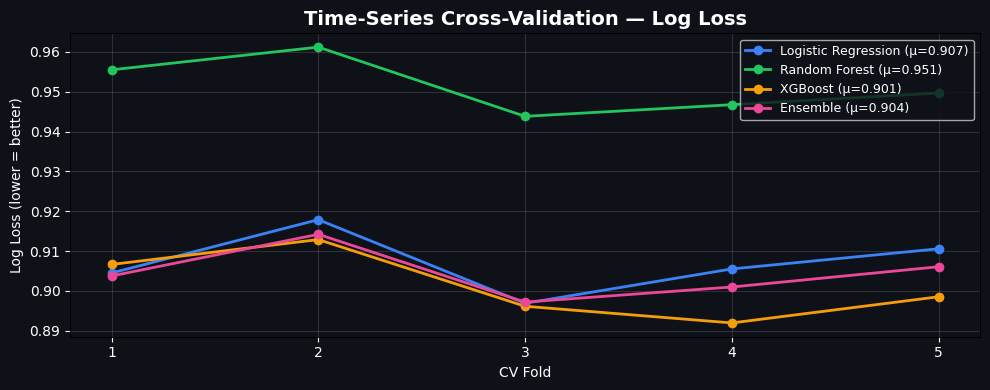

Saved cv_logloss.png


In [5]:
# CV runs on training data only — never touches test set
tscv = TimeSeriesSplit(n_splits=5)

print('⚙️  Running 5-fold time-series cross-validation on training data...')
print(f'   {len(X_train):,} training rows\n')

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=tscv, scoring='neg_log_loss', n_jobs=-1
    )
    log_loss_scores = -scores   # flip sign: lower is better
    cv_results[name] = log_loss_scores
    print(f'  {name:<25} CV log-loss: {log_loss_scores.mean():.4f} ± {log_loss_scores.std():.4f}')
    print(f'  {"":<25} Per fold   : {[round(s, 4) for s in log_loss_scores]}')
    print()

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#3b82f6', '#22c55e', '#f59e0b', '#ec4899']
for (name, scores), color in zip(cv_results.items(), colors):
    ax.plot(range(1, 6), scores, marker='o',
            label=f'{name} (μ={scores.mean():.3f})',
            color=color, linewidth=2)

ax.set_xlabel('CV Fold')
ax.set_ylabel('Log Loss (lower = better)')
ax.set_title('Time-Series Cross-Validation — Log Loss', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xticks(range(1, 6))
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'cv_logloss.png', dpi=120, bbox_inches='tight', facecolor='#0e1117')
plt.show()
print('Saved cv_logloss.png')

---
## 4. Train on Pre-2015 → calibrating on 2015 -2017 -> Evaluate on 2018+2022 WC

In [6]:
print('⚙️  Training on pre-2015 data, calibrating on 2015–2017, evaluating on 2018+...\n')

trained_models     = {}
calibrated_models  = {}
test_results       = {}

for name, model in models.items():
    # Step 1 — fit on training slice
    if name == 'XGBoost':
        model.fit(X_train, y_train, sample_weight=sample_weights_train)
    else:
        model.fit(X_train, y_train)

    # Step 2 — calibrate (skip for LR — already well calibrated)
    if name == 'Logistic Regression':
        cal_model = model
    else:
        cal_model = CalibratedClassifierCV(model, cv=None, method='isotonic')
        cal_model.fit(X_cal, y_cal)

    trained_models[name]    = model
    calibrated_models[name] = cal_model

    # Step 3 — evaluate on full test set
    y_pred      = cal_model.predict(X_test)
    y_proba     = cal_model.predict_proba(X_test)
    acc         = accuracy_score(y_test, y_pred)
    ll          = log_loss(y_test, y_proba)

    # Step 4 — evaluate on WC-only slice
    y_pred_wc   = cal_model.predict(X_test_wc)
    acc_wc      = accuracy_score(y_test_wc, y_pred_wc)
    ll_wc       = log_loss(y_test_wc, cal_model.predict_proba(X_test_wc))

    test_results[name] = {
        'accuracy': acc, 'log_loss': ll,
        'acc_wc': acc_wc, 'll_wc': ll_wc,
        'y_pred': y_pred, 'model': cal_model
    }
    print(f'  {name:<25}  All: Acc={acc:.4f} LL={ll:.4f}  '
          f'| WC: Acc={acc_wc:.4f} LL={ll_wc:.4f}')

# Baseline
baseline_acc = (y_test == 2).mean()
print(f'\n  {"Baseline (always Home win)":<25}  Accuracy: {baseline_acc:.4f}')

# Detailed report for best model by log loss
best_name = min(test_results, key=lambda n: test_results[n]['log_loss'])
print(f'\nBest model (log loss): {best_name}\n')
print(classification_report(
    y_test,
    test_results[best_name]['y_pred'],
    target_names=['Away Win', 'Draw', 'Home Win']
))

⚙️  Training on pre-2015 data, calibrating on 2015–2017, evaluating on 2018+...

  Logistic Regression        All: Acc=0.6102 LL=0.8599  | WC: Acc=0.6016 LL=0.8669
  Random Forest              All: Acc=0.5978 LL=0.9041  | WC: Acc=0.5312 LL=1.0071
  XGBoost                    All: Acc=0.6067 LL=0.8822  | WC: Acc=0.6250 LL=0.8695
  Ensemble                   All: Acc=0.6071 LL=0.8737  | WC: Acc=0.6328 LL=0.8613

  Baseline (always Home win)  Accuracy: 0.4775

Best model (log loss): Logistic Regression

              precision    recall  f1-score   support

    Away Win       0.59      0.63      0.61      2354
        Draw       0.49      0.05      0.08      1865
    Home Win       0.62      0.87      0.73      3856

    accuracy                           0.61      8075
   macro avg       0.57      0.52      0.47      8075
weighted avg       0.58      0.61      0.54      8075



In [7]:
# ── Draw threshold tuning ────────────────────────────────────────
from sklearn.metrics import f1_score


print('\n⚙️  Tuning draw threshold on test set...\n')

proba = calibrated_models['Ensemble'].predict_proba(X_test)
best_thresh, best_f1, best_report = 0.33, 0, None

for thresh in np.arange(0.20, 0.45, 0.01):
    y_pred_thresh = np.where(
        proba[:, 1] >= thresh, 1,
        np.where(proba[:, 0] >= proba[:, 2], 0, 2)
    )
    f1 = f1_score(y_test, y_pred_thresh, average='macro')
    if f1 > best_f1:
        best_f1      = f1
        best_thresh  = thresh
        best_report  = classification_report(
            y_test, y_pred_thresh,
            target_names=['Away Win', 'Draw', 'Home Win']
        )

DRAW_THRESHOLD = best_thresh
print(f'Optimal draw threshold : {DRAW_THRESHOLD:.2f}')
print(f'Best macro-F1          : {best_f1:.4f}')
print(best_report)


⚙️  Tuning draw threshold on test set...

Optimal draw threshold : 0.29
Best macro-F1          : 0.5399
              precision    recall  f1-score   support

    Away Win       0.62      0.51      0.56      2354
        Draw       0.33      0.44      0.38      1865
    Home Win       0.71      0.66      0.68      3856

    accuracy                           0.57      8075
   macro avg       0.55      0.54      0.54      8075
weighted avg       0.59      0.57      0.58      8075



Best Model

In [8]:
# Detailed classification report for best model (by accuracy)
best_name = max(test_results, key=lambda n: test_results[n]['accuracy'])
print(f'Best model: {best_name}\n')
print(classification_report(
    y_test,
    test_results[best_name]['y_pred'],
    target_names=['Away Win', 'Draw', 'Home Win']
))

Best model: Logistic Regression

              precision    recall  f1-score   support

    Away Win       0.59      0.63      0.61      2354
        Draw       0.49      0.05      0.08      1865
    Home Win       0.62      0.87      0.73      3856

    accuracy                           0.61      8075
   macro avg       0.57      0.52      0.47      8075
weighted avg       0.58      0.61      0.54      8075



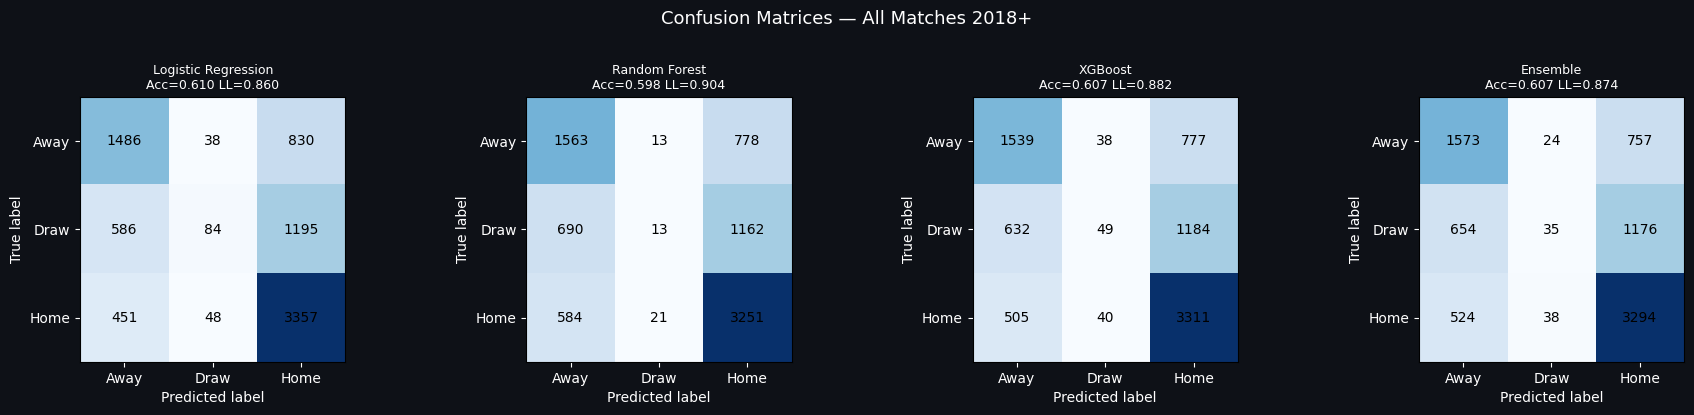

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.patch.set_facecolor('#0e1117')

for ax, (name, res) in zip(axes, test_results.items()):
    cm   = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Away', 'Draw', 'Home'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc={res["accuracy"]:.3f} LL={res["log_loss"]:.3f}',
                 color='white', fontsize=9)
    ax.set_facecolor('#0e1117')
    for text in ax.texts:
        text.set_color('black')

plt.suptitle('Confusion Matrices — All Matches 2018+', color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'confusion_matrices.png', dpi=120,
            bbox_inches='tight', facecolor='#0e1117')
plt.show()

---
## 5. WC-Only Cross-Validation

Train only on WC matches — smaller dataset but most relevant signal for WC prediction.

In [10]:
# 3 folds — more stable on 552 WC matches
tscv_wc = TimeSeriesSplit(n_splits=3)

print('⚙️  WC-only cross-validation (3-fold time-series on WC matches)...\n')

wc_cv_results = {}
for name, model in models.items():
    scores = cross_val_score(
        model, X_wc, y_wc,
        cv=tscv_wc, scoring='neg_log_loss'
    )
    ll_scores = -scores
    wc_cv_results[name] = ll_scores
    print(f'  {name:<25}  WC CV log-loss: {ll_scores.mean():.4f} ± {ll_scores.std():.4f}')

⚙️  WC-only cross-validation (3-fold time-series on WC matches)...

  Logistic Regression        WC CV log-loss: 1.0362 ± 0.0701
  Random Forest              WC CV log-loss: 1.0050 ± 0.0474
  XGBoost                    WC CV log-loss: 1.0411 ± 0.0951
  Ensemble                   WC CV log-loss: 0.9499 ± 0.0403


---
## 6. Feature Importance

⚙️  Checking feature correlations...
⚠️  Highly correlated pairs (>0.9):
   h2h_games ↔ h2h_draws: 0.918

⚙️  Training XGBoost and RF on full dataset for feature importance...


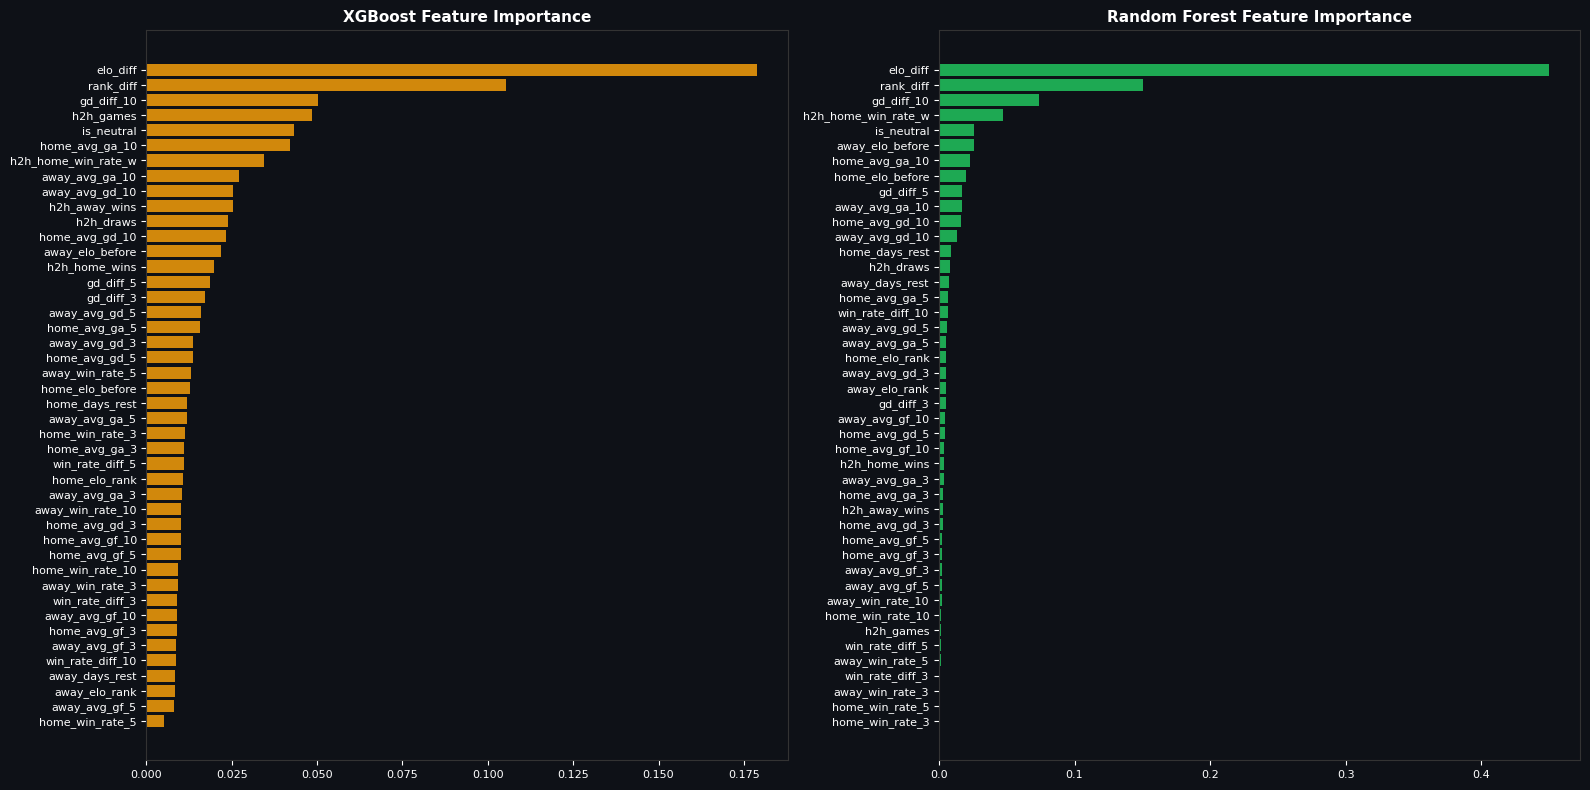


Top 10 features (avg XGBoost + RF):


,feature,xgb,rf,avg
0,elo_diff,0.178840,0.450373,0.314607
1,rank_diff,0.105229,0.150576,0.127902
2,gd_diff_10,0.050174,0.073908,0.062041
3,h2h_home_win_rate_w,0.034285,0.047336,0.040810
4,is_neutral,0.043143,0.025724,0.034434
5,home_avg_ga_10,0.042016,0.023226,0.032621
6,h2h_games,0.048352,0.001648,0.025000
7,away_elo_before,0.021967,0.025720,0.023843
8,away_avg_ga_10,0.027035,0.016746,0.021891
9,home_avg_gd_10,0.023443,0.015963,0.019703


In [11]:
# Correlation check first
print('⚙️  Checking feature correlations...')
corr_matrix = X_all.corr().abs()
high_corr = [
    (FEATURE_COLS[i], FEATURE_COLS[j], corr_matrix.iloc[i, j])
    for i in range(len(FEATURE_COLS))
    for j in range(i + 1, len(FEATURE_COLS))
    if corr_matrix.iloc[i, j] > 0.9
]
if high_corr:
    print('⚠️  Highly correlated pairs (>0.9):')
    for a, b, c in sorted(high_corr, key=lambda x: -x[2]):
        print(f'   {a} ↔ {b}: {c:.3f}')
else:
    print('✅ No feature pairs above 0.9 correlation')

# Train on full dataset for importance
print('\n⚙️  Training XGBoost and RF on full dataset for feature importance...')
xgb_full = XGBClassifier(
    **xgb_search.best_params_,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)
sample_weights_all = compute_sample_weight(class_weight='balanced', y=y_all)
xgb_full.fit(X_all, y_all, sample_weight = sample_weights_all)

rf_full = RandomForestClassifier(
    **rf_search.best_params_,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_full.fit(X_all, y_all)



# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('#0e1117')

for ax, model_full, title, color in [
    (ax1, xgb_full, 'XGBoost Feature Importance', '#f59e0b'),
    (ax2, rf_full,  'Random Forest Feature Importance', '#22c55e')
]:
    importances = model_full.feature_importances_
    sorted_idx  = np.argsort(importances)
    ax.barh([FEATURE_COLS[i] for i in sorted_idx],
            importances[sorted_idx], color=color, alpha=0.85)
    ax.set_facecolor('#0e1117')
    ax.set_title(title, color='white', fontsize=11, fontweight='bold')
    ax.tick_params(colors='white', labelsize=8)
    ax.spines[['top', 'right', 'bottom', 'left']].set_color('#333')

plt.tight_layout()
plt.savefig(MODEL_DIR / 'feature_importance.png', dpi=120,
            bbox_inches='tight', facecolor='#0e1117')
plt.show()

# Top 10 by average importance
fi_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'xgb':     xgb_full.feature_importances_,
    'rf':       rf_full.feature_importances_
})
fi_df['avg'] = (fi_df['xgb'] + fi_df['rf']) / 2
print('\nTop 10 features (avg XGBoost + RF):')
display(fi_df.sort_values('avg', ascending=False).head(10).reset_index(drop=True))

---
## 7. Probability Calibration

Raw model probabilities can be overconfident. We use Platt scaling to calibrate them — this is crucial for tournament simulation.

In [12]:
# ── Final ensemble from already-calibrated models ────────────────────────────


final_ensemble = VotingClassifier(
    estimators=[
        ('lr',  calibrated_models['Logistic Regression']),
        ('rf',  calibrated_models['Random Forest']),
        ('xgb', calibrated_models['XGBoost']),
    ],
    voting='soft',
    weights=[2.5, 0.9, 3]   # LR strongest on log loss, RF weakest on WC
)
final_ensemble.fit(X_train, y_train)   # fit the voting wrapper only

# Verify probabilities sum to 1
sample_probs = final_ensemble.predict_proba(X_test.iloc[:5])
prob_df = pd.DataFrame(sample_probs, columns=['P(Away)', 'P(Draw)', 'P(Home)'])
prob_df['home_team'] = df_all[test_mask].iloc[:5]['home_team'].values
prob_df['away_team'] = df_all[test_mask].iloc[:5]['away_team'].values
display(prob_df[['home_team', 'away_team', 'P(Home)', 'P(Draw)', 'P(Away)']])
print(f'\nProb sums (should all be 1.0): {sample_probs.sum(axis=1).round(4)}')

,home_team,away_team,P(Home),P(Draw),P(Away)
0,Iraq,United Arab Emirates,0.422611,0.306975,0.270414
1,Oman,Bahrain,0.512734,0.263546,0.223721
2,Oman,United Arab Emirates,0.346073,0.281553,0.372374
3,Estonia,Sweden,0.155155,0.275799,0.569046
4,Jordan,Finland,0.418548,0.300013,0.281439



Prob sums (should all be 1.0): [1. 1. 1. 1. 1.]


---
## 8. Model Summary & Selection

In [13]:
summary = pd.DataFrame([
    {
        'Model':              name,
        'CV Log-Loss (all)':  f"{cv_results[name].mean():.4f} ± {cv_results[name].std():.4f}",
        'CV Log-Loss (WC)':   f"{wc_cv_results[name].mean():.4f} ± {wc_cv_results[name].std():.4f}",
        'Test Accuracy (all)':f"{test_results[name]['accuracy']:.4f}",
        'Test Accuracy (WC)': f"{test_results[name]['acc_wc']:.4f}",
        'Test Log-Loss (all)':f"{test_results[name]['log_loss']:.4f}",
        'Test Log-Loss (WC)': f"{test_results[name]['ll_wc']:.4f}",
    }
    for name in models
])

print('=' * 80)
print('MODEL COMPARISON SUMMARY')
print('=' * 80)
display(summary)
print(f'\n✅ Selected model: Final Ensemble')
print(f'   Draw threshold : {DRAW_THRESHOLD:.2f}')

MODEL COMPARISON SUMMARY


,Model,CV Log-Loss (all),CV Log-Loss (WC),Test Accuracy (all),Test Accuracy (WC),Test Log-Loss (all),Test Log-Loss (WC)
0,Logistic Regression,0.9071 ± 0.0069,1.0362 ± 0.0701,0.6102,0.6016,0.8599,0.8669
1,Random Forest,0.9514 ± 0.0062,1.0050 ± 0.0474,0.5978,0.5312,0.9041,1.0071
2,XGBoost,0.9013 ± 0.0075,1.0411 ± 0.0951,0.6067,0.6250,0.8822,0.8695
3,Ensemble,0.9045 ± 0.0057,0.9499 ± 0.0403,0.6071,0.6328,0.8737,0.8613



✅ Selected model: Final Ensemble
   Draw threshold : 0.29


---
## 9. Save Models to Disk

In [14]:
save_data = {
    'final_ensemble':    final_ensemble,
    'calibrated_models': calibrated_models,
    'feature_cols':      FEATURE_COLS,
    'draw_threshold':    DRAW_THRESHOLD,
    'target':            TARGET,
    'xgb_best_params':   xgb_search.best_params_,
    'rf_best_params':    rf_search.best_params_,
}

with open(MODEL_DIR / 'models.pkl', 'wb') as f:
    pickle.dump(save_data, f)

# Sanity check — reload and verify
with open(MODEL_DIR / 'models.pkl', 'rb') as f:
    loaded = pickle.load(f)

assert loaded['feature_cols'] == FEATURE_COLS, "Feature cols mismatch"
assert 'final_ensemble' in loaded, "Ensemble missing"
assert 'draw_threshold' in loaded, "Draw threshold missing"

print('✅ models.pkl saved and verified')
print(f'   Keys: {list(loaded.keys())}')
for f in sorted(MODEL_DIR.glob('*.pkl')):
    print(f'  📦 {f.name:<35} {os.path.getsize(f)/1024:>7.1f} KB')

✅ models.pkl saved and verified
   Keys: ['final_ensemble', 'calibrated_models', 'feature_cols', 'draw_threshold', 'target', 'xgb_best_params', 'rf_best_params']
  📦 feature_cols.pkl                        0.4 KB
  📦 final_ensemble.pkl                  121175.1 KB
  📦 models.pkl                          118994.9 KB
  📦 poisson_model.pkl                       8.6 KB
  📦 rf_calibrated.pkl                   49840.1 KB
  📦 xgb_calibrated.pkl                  10635.8 KB
